<a href="https://colab.research.google.com/github/Alone1011/SpeechProcessing-Genap-6/blob/main/Tugas_1/2311532011_RifkiYuliandra_Script.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PERSIAPAN ENVIRONMENT**

In [ ]:
# Jalankan sel ini pertama kali untuk menginstal library tambahan
!pip install noisereduce

import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import soundfile as sf
import noisereduce as nr

# 1. Unggah file audio yang sudah direkam
file_path = '2311532011-RifkiYuliandra-audio.wav'

# Load audio
y, sr = librosa.load(file_path, sr=None)
print(f"Sampling Rate: {sr} Hz")

/tmp/ipykernel_908/1718720886.py:16: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(file_path, sr=None)


Sampling Rate: 48000 Hz


# **MEMVISUALISASIKAN WAVEFORM**

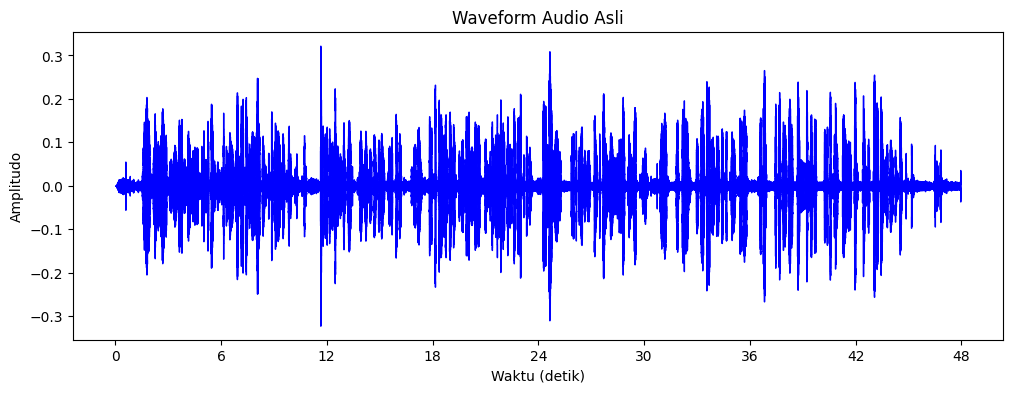

In [ ]:
plt.figure(figsize=(12, 4))
librosa.display.waveshow(y, sr=sr, color='blue')
plt.title('Waveform Audio Asli')
plt.xlabel('Waktu (detik)')
plt.ylabel('Amplitudo')
plt.show()

Berdasarkan grafik tersebut, berikut adalah hasil analisis pengamatannya:
* **Keberadaan Silence (Bagian Diam):** Terdapat beberapa bagian silence (jeda bicara) dalam rekaman. Jeda yang cukup panjang terlihat jelas pada area sekitar detik ke-11 hingga 12, dan detik ke-24 hingga 25. Selain itu, terdapat jeda-jeda yang lebih singkat di sepanjang grafik yang menandakan spasi antar kata atau tarikan napas saat berbicara.
* **Pola Amplitudo Suara:** Pola amplitudo terlihat sangat fluktuatif, merepresentasikan dinamika volume suara Anda saat berbicara. Sebagian besar suara vokal yang stabil berada pada rentang amplitudo -0.2 hingga 0.2. Terdapat beberapa lonjakan amplitudo tajam (bagian suara yang keras) yang mencapai angka lebih dari 0.3 (seperti pada sekitar detik ke-12 dan detik ke-25), yang kemungkinan disebabkan oleh penekanan nada bicara atau hembusan udara (plosive sound) yang mengenai mikrofon.
* **Keberadaan Noise:** Jika diamati pada bagian silence atau jeda (di mana grafik mendekati angka 0), garis amplitudonya tidak benar-benar datar atau tipis sempurna. Terdapat sedikit penebalan atau getaran kecil pada garis dasar (baseline) tersebut. Hal ini mengindikasikan adanya noise latar belakang (background noise), seperti suara dengungan ruangan, suara angin, atau statis dari perangkat keras saat merekam suara.

# **MEMBUAT SPECTROGRAM**

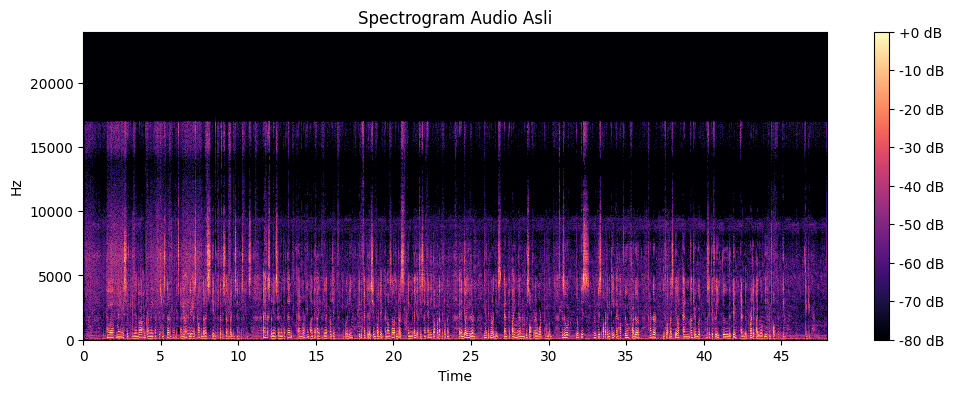

In [ ]:
# Menghitung Short-Time Fourier Transform (STFT)
D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)

plt.figure(figsize=(12, 4))
librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='hz', cmap='magma')
plt.colorbar(format='%+2.0f dB')
plt.title('Spectrogram Audio Asli')
plt.show()

Grafik spectrogram di atas adalah representasi visual yang menunjukkan sumbu X sebagai waktu, sumbu Y sebagai frekuensi, dan warna sebagai intensitas energi. Pada area colorbar di sebelah kanan, terlihat rentang warna dari gelap (hitam/ungu tua mewakili energi rendah atau -80 dB) hingga terang (oranye/kuning mewakili energi tinggi atau mendekati 0 dB).

Berdasarkan spectrogram yang dihasilkan, berikut adalah penjelasan komponen frekuensi dalam sinyal suara tersebut:


1. **Frekuensi Dominan:** Frekuensi dominan dalam suara berada pada rentang frekuensi rendah, yakni secara padat terkonsentrasi di bawah 5.000 Hz, dan sangat intens di area 0 – 2.000 Hz. Hal ini terlihat jelas dari dominasi warna paling terang (kuning dan oranye muda) di bagian bawah grafik. Ini adalah karakteristik normal dari suara manusia, di mana rentang tersebut memuat frekuensi dasar (F0) dan formant (resonansi saluran suara) saat seseorang berbicara.


2. **Pola Harmonik:** Terdapat pola harmonik yang terlihat sangat jelas pada rentang frekuensi rendah hingga menengah. Pola ini direpresentasikan oleh garis-garis horizontal yang rapat, bertumpuk paralel, dan terdistribusi secara beraturan. Garis-garis ini merupakan kelipatan frekuensi dari frekuensi dasar (F0) dan biasanya muncul sangat tegas saat pita suara bergetar untuk mengucapkan huruf-huruf vokal (seperti a, i, u, e, o).


3. **Distribusi Energi Frekuensi:** Distribusi energi frekuensi cukup bervariasi bergantung pada kata yang diucapkan. Energi suara mayoritas mengumpul di bagian bawah (suara vokal). Namun, terdapat pilar-pilar atau kilatan energi vertikal yang menyebar hingga ke frekuensi tinggi (mencapai sekitar 10.000 – 15.000 Hz). Kilatan ini biasanya terbentuk akibat pelafalan suara konsonan tanpa nada, frikatif, atau plosif (seperti pengucapan bunyi 's', 'sy', 't', atau 'p'). Selain itu, terlihat cutoff (potongan) pita frekuensi yang sangat tajam berupa area hitam pekat di atas angka ±16.500 Hz; ini mengindikasikan adanya batasan perekaman dari hardware mikrofon atau kompresi format audio dari perangkat keras. Pendaran ungu redup di latar belakang pada area yang tidak ada suaranya juga menunjukkan keberadaan noise statis atau background noise.

# **MELAKUKAN PREPROCESSING SEDERHANA**

In [ ]:
# Pastikan library noisereduce, soundfile, numpy, dan librosa sudah di-import
# dan variabel 'y' (audio asli) serta 'sr' (sampling rate) sudah diload dari Langkah 1

# a. Normalization
# Menyesuaikan amplitudo sinyal agar berada dalam rentang -1 hingga 1
y_norm = y / np.max(np.abs(y))

# b. Silence Removal
# Menghapus bagian rekaman yang diam (silence) di bawah threshold 20 dB
y_trim, index = librosa.effects.trim(y_norm, top_db=20)

# c. Noise Reduction
# Mengurangi noise latar belakang menggunakan library noisereduce
y_clean = nr.reduce_noise(y=y_trim, sr=sr)

# --- MENYIMPAN FILE HASIL PREPROCESSING ---
# File Audio hasil preprocessing sampai point 3 (Noise Reduction)
# INGAT: Ubah '210312345-andi' menjadi NIM dan Nama Anda
sf.write('2311532011-RifkiYuliandra-preprocessing.wav', y_clean, sr)

# d. Framing
# Memecah sinyal menjadi frame-frame kecil.
# Kita gunakan frame_length 2048 sampel dan hop_length 512 sampel.
frame_length = 2048
hop_length = 512
frames = librosa.util.frame(y_clean, frame_length=frame_length, hop_length=hop_length)

# e. Windowing
# Menerapkan fungsi Hamming Window pada setiap frame untuk menghaluskan ujung sinyal
window = np.hamming(frame_length)
# Mengalikan setiap frame dengan fungsi window
frames_windowed = frames * window[:, np.newaxis]

# --- MENYIMPAN FILE HASIL WINDOWING ---
# Kumpulan suara hasil framing dan windowing
# Untuk contoh ini, kita simpan 5 frame pertama saja agar tidak terlalu banyak file
for i in range(5):
    file_name = f'2311532011-RifkiYuliandra-windowing-{i+1}.wav'
    sf.write(file_name, frames_windowed[:, i], sr)

print("Langkah 4 Selesai: Normalisasi, Silence Removal, Noise Reduction, Framing, dan Windowing berhasil dilakukan!")
print("File 'preprocessing.wav' dan 'windowing-n.wav' telah disimpan.")

Langkah 4 Selesai: Normalisasi, Silence Removal, Noise Reduction, Framing, dan Windowing berhasil dilakukan!
File 'preprocessing.wav' dan 'windowing-n.wav' telah disimpan.


# **MEMBANDINGKAN HASIL ANALISIS**

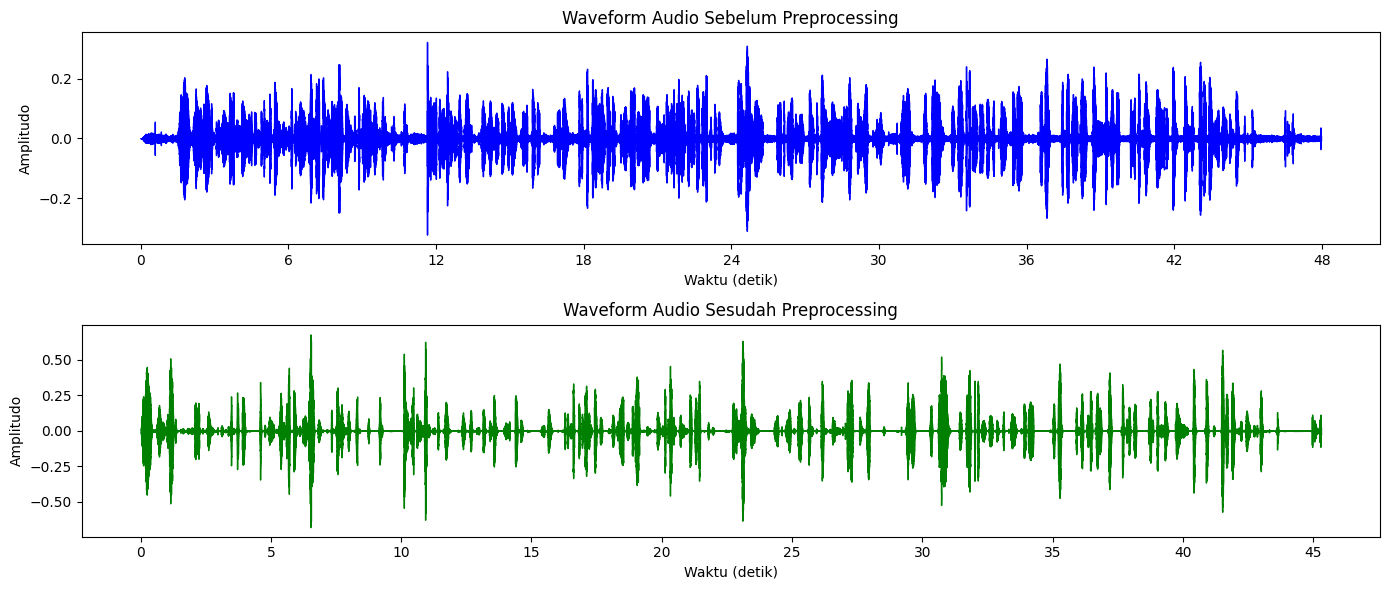

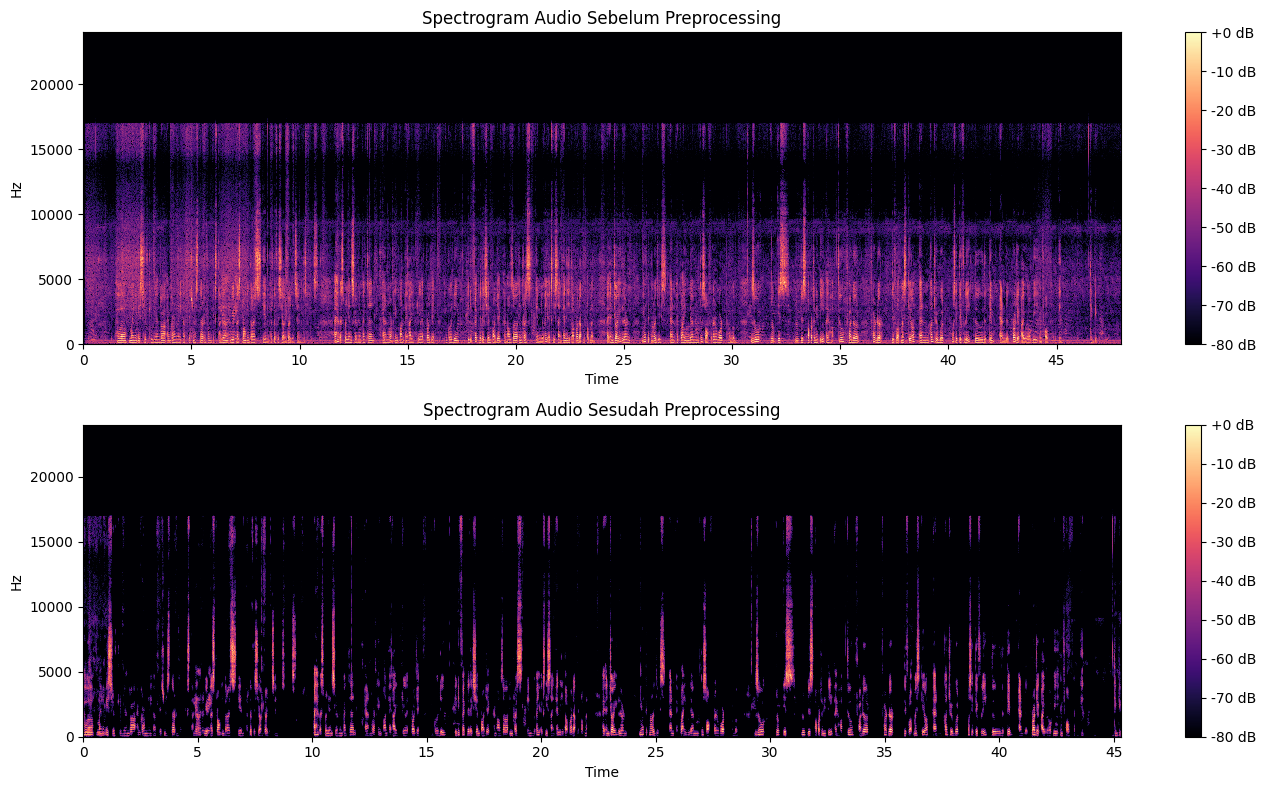

In [ ]:
# Pastikan variabel 'y' (audio asli), 'y_clean' (audio setelah preprocessing), dan 'sr' (sampling rate) sudah ada di memori

# 1. Perbandingan Waveform
plt.figure(figsize=(14, 6))

# Waveform Sebelum Preprocessing
plt.subplot(2, 1, 1)
librosa.display.waveshow(y, sr=sr, color='blue')
plt.title('Waveform Audio Sebelum Preprocessing')
plt.xlabel('Waktu (detik)')
plt.ylabel('Amplitudo')

# Waveform Sesudah Preprocessing
plt.subplot(2, 1, 2)
librosa.display.waveshow(y_clean, sr=sr, color='green')
plt.title('Waveform Audio Sesudah Preprocessing')
plt.xlabel('Waktu (detik)')
plt.ylabel('Amplitudo')

plt.tight_layout()
plt.show()

# 2. Perbandingan Spectrogram
# Menghitung STFT untuk audio yang sudah di-preprocess
D_clean = librosa.amplitude_to_db(np.abs(librosa.stft(y_clean)), ref=np.max)

plt.figure(figsize=(14, 8))

# Spectrogram Sebelum Preprocessing
plt.subplot(2, 1, 1)
librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='hz', cmap='magma')
plt.colorbar(format='%+2.0f dB')
plt.title('Spectrogram Audio Sebelum Preprocessing')

# Spectrogram Sesudah Preprocessing
plt.subplot(2, 1, 2)
librosa.display.specshow(D_clean, sr=sr, x_axis='time', y_axis='hz', cmap='magma')
plt.colorbar(format='%+2.0f dB')
plt.title('Spectrogram Audio Sesudah Preprocessing')

plt.tight_layout()
plt.show()

Melalui grafik perbandingan antara audio sebelum dan sesudah tahap preprocessing, terlihat jelas efektivitas dari metode yang diimplementasikan pada program. Berikut adalah rincian perubahannya:

1. **Perubahan Waveform:**

    * **Skala Amplitudo:** Amplitudo puncak pada audio asli hanya berada di kisaran ±0.3. Setelah dilakukan Normalization, rentang amplitudo diskalakan secara proporsional sehingga meningkat hingga di atas ±0.5 (mendekati batas maksimal). Hal ini membuat volume audio secara keseluruhan menjadi lebih kuat dan berstandar.

    * **Kondisi Silence:** Pada grafik audio asli (biru), area jeda bicara masih menampilkan getaran-getaran amplitudo kecil yang merupakan wujud dari noise mikrofon. Pada grafik audio sesudah preprocessing (hijau), area jeda tersebut menjadi garis lurus yang benar-benar datar di angka 0 berkat kombinasi Noise Reduction dan Silence Removal.

    * **Durasi Sinyal:** Terlihat sedikit pemendekan durasi total di sumbu X, dari sekitar 48 detik menjadi sekitar 45.5 detik. Ini mengindikasikan bahwa Silence Removal berhasil membuang bagian kosong (suara diam di bawah batas 20 dB), terutama di awal dan akhir rekaman.

2. **Perubahan Spectrogram:**

    * **Pembersihan Noise Hiss/Statis:** Pada spectrogram atas (sebelum preprocessing), terdapat "kabut" atau pendaran berwarna ungu redup yang menyelimuti seluruh rentang waktu dan frekuensi. Kabut ini adalah background noise yang terekam. Pada spectrogram bawah, efek dari Noise Reduction sangat kentara karena latar belakangnya kini berubah menjadi hitam pekat (energi ditekan ke -80 dB).

    * **Kontras Frekuensi Utama:** Dengan hilangnya energi noise di latar belakang, energi suara utama Anda (yang direpresentasikan oleh garis dan pilar berwarna oranye/kuning/merah muda) menjadi jauh lebih tajam dan kontras. Pola-pola harmonik vokal juga menjadi lebih bersih dari distorsi.

3. **Perubahan Kualitas Sinyal:**

    Secara keseluruhan, kualitas sinyal audio meningkat secara signifikan. Sinyal kini lebih lantang, lebih padat (karena terbebas dari silence yang tidak perlu), dan sangat jernih. Kondisi sinyal yang "bersih" ini merupakan tujuan utama dari speech preprocessing, karena akan sangat memudahkan model komputasi atau algoritma Machine Learning untuk mengekstrak fitur suara tanpa terganggu oleh variabel noise.